# Python Lesson 16: Rank of a Matrix

**Concept page:** `wiki/concepts/rank.md` · **Area:** linear-algebra

**You will be able to:**
- compute rank by NumPy and by counting pivots
- relate rank to image dimension and null space
- low-rank approximation of an image-like matrix

*How to use:* run the cells top to bottom, read the output, then try the **Exercises** in the empty cells before opening the **Solutions** section at the bottom.

In [1]:
import numpy as np
import sympy as sp
import matplotlib
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True)
%matplotlib inline

## 1. Pieces of information

In [2]:
for A in ([[1,1],[1,2]],[[1,1],[2,2]],[[0,0],[0,0]]):
    print(A,"rank",np.linalg.matrix_rank(np.array(A,float)))

[[1, 1], [1, 2]] rank 2
[[1, 1], [2, 2]] rank 1
[[0, 0], [0, 0]] rank 0


## 2. rank + nullity = n

In [3]:
A=np.array([[1,1,1],[1,2,1],[1,1,1]],float)
from scipy.linalg import null_space
r=np.linalg.matrix_rank(A); N=null_space(A); print("rank",r,"nullity",N.shape[1],"sum",r+N.shape[1])

rank 2 nullity 1 sum 3


## 3. Reducing rank compresses data (SVD)

1 relative error 0.1417
2 relative error 0.0184
5 relative error 0.0167


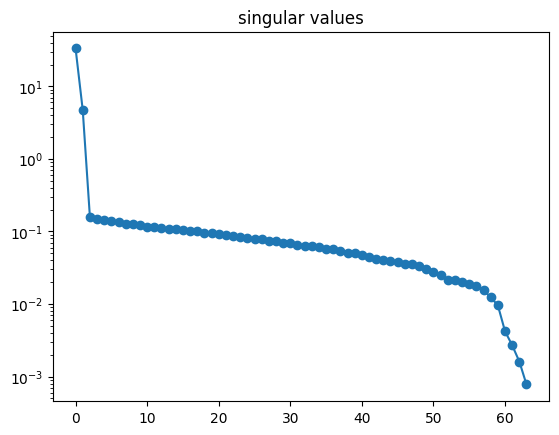

In [4]:
x=np.linspace(0,1,64); img=np.outer(np.sin(6*x),np.cos(5*x))+0.3*np.outer(x,x)+0.01*np.random.default_rng(0).normal(size=(64,64))
U,s,Vt=np.linalg.svd(img)
for k in (1,2,5):
    approx=(U[:,:k]*s[:k])@Vt[:k]; print(k,"relative error",round(np.linalg.norm(img-approx)/np.linalg.norm(img),4))
plt.semilogy(s,'o-'); plt.title("singular values"); plt.show()

## Cambodian textbook corner (កម្មវិធីសិក្សាកម្ពុជា)
Grade 11 basic: the book decides invertibility with the determinant; rank is the Coursera view of the same fact.

In [5]:
print(np.linalg.matrix_rank(np.array([[3,4],[1,2]])), np.linalg.det(np.array([[3,4],[1,2]])))

2 2.0000000000000004


## Rank and the dimension of the solution space
For $A\mathbf x=\mathbf 0$: rank + nullity = number of unknowns (C1 week 2 slides: rank 2, 1, 0 give solution sets of dimension 0, 1, 2).

In [6]:
for M in ([[1,1],[1,2]],[[1,1],[2,2]],[[0,0],[0,0]]):
    A=sp.Matrix(M); r=A.rank(); nul=len(A.nullspace()); print(M,'rank',r,'nullity',nul)
    assert r+nul==A.shape[1]

[[1, 1], [1, 2]] rank 2 nullity 0
[[1, 1], [2, 2]] rank 1 nullity 1
[[0, 0], [0, 0]] rank 0 nullity 2


## Exercises

**Exercise 1.** What is the rank of the 3x3 matrices [[1,1,1],[1,2,1],[1,1,2]], [[1,1,1],[1,1,2],[1,1,3]], [[1,1,1],[2,2,2],[3,3,3]]? (3,2,1)

In [7]:
# your code here

**Exercise 2.** Show that rank(AB) <= min(rank A, rank B) on random matrices.

In [8]:
# your code here

## Solutions
*(Try the exercises first!)*

In [9]:
# Solution 1
print([np.linalg.matrix_rank(np.array(m,float)) for m in ([[1,1,1],[1,2,1],[1,1,2]],[[1,1,1],[1,1,2],[1,1,3]],[[1,1,1],[2,2,2],[3,3,3]])])

[np.int64(3), np.int64(2), np.int64(1)]


In [10]:
# Solution 2
rng=np.random.default_rng(0);A=rng.normal(size=(5,2))@rng.normal(size=(2,5));B=rng.normal(size=(5,5)); r=np.linalg.matrix_rank; assert r(A@B)<=min(r(A),r(B))